# Прогноз спроса на аренду велосипедов

Датасет Сеул 2019 год

## Задача

На основе датасета https://www.kaggle.com/datasets/joebeachcapital/seoul-bike-sharing посторить модель с наилучшими результами прогноза на аренду велосипедов в зависимости от признаком.

Для этого мы должны:
1) Обработать, преобразовать данные;
2) Добавить дополнительные признаки;
3) Проанализировать полученный набор данных
4) Реализовать baseline для предсказания с помощью модели LinearRegression
5) Проверить другие модели и выбрать лучшую из:
    - RidgeCV
    - LassoCV
    - ElasticNetCV
    - RandomForestRegressor
    - GradientBoostingRegressor
    - CatBoostRegressor

In [ ]:
!pip install kaggle
!pip install catboost

In [12]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression,RidgeCV,LassoCV,ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from catboost import CatBoostRegressor

import joblib

import warnings
warnings.filterwarnings('ignore')


In [17]:
os.makedirs('./data', exist_ok=True)
!kaggle datasets download -d joebeachcapital/seoul-bike-sharing -p ./data

zip_path = './data/seoul-bike-sharing.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('./data')

if os.path.exists(zip_path):
    os.remove(zip_path)
    print(f"Файл {zip_path} успешно удален")
else:
    print(f"Файл {zip_path} не найден")

Dataset URL: https://www.kaggle.com/datasets/joebeachcapital/seoul-bike-sharing
License(s): DbCL-1.0

Файл ./data/seoul-bike-sharing.zip успешно удален



  0%|          | 0.00/126k [00:00<?, ?B/s]
100%|██████████| 126k/126k [00:00<00:00, 1.31MB/s]


In [104]:
df = pd.read_csv('./data/SeoulBikeData.csv', encoding='latin1')
print("Данные успешно загружены!")
print(f"Размер датасета: {df.shape}")
df.head()


Данные успешно загружены!
Размер датасета: (8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

In [26]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

## Готовим, преобразуем и добавляем признаки в наборе данных

In [2]:
df = pd.read_csv('./data/SeoulBikeData.csv', encoding='latin1')

# Словари
columns_translation = {
    'Rented Bike Count': 'Арендовано велосипедов',
    'Hour': 'Час',
    'Temperature(°C)': 'Температура (°C)',
    'Humidity(%)': 'Влажность (%)',
    'Wind speed (m/s)': 'Скорость ветра (м/с)',
    'Visibility (10m)': 'Видимость (10м)',
    'Dew point temperature(°C)': 'Точка росы (°C)',
    'Solar Radiation (MJ/m2)': 'Солнечная радиация (МДж/м²)',
    'Rainfall(mm)': 'Осадки (мм)',
    'Snowfall (cm)': 'Снегопад (см)',
    'Seasons': 'Сезон',
    'Holiday': 'Праздник',
    'Functioning Day': 'Рабочий день',
    'Day': 'День',
    'Weekday': 'День недели',
    'Month': 'Месяц',
    'Year': 'Год'
}
seasons_dict = {'Spring': 0, 'Summer': 1, 'Autumn': 2, 'Winter': 3}
holiday_dict = {'No Holiday': 0,'Holiday': 1}
functioning_day_dict = {'No': 0,'Yes': 1}
weekday_dict = {'Friday': 4, 'Saturday': 5, 'Sunday': 6, 'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3}

# Конвертируем формат времени
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Обработка даты, делаем дополнительные признаки день, день недели, месяц, год
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()
df['Month'] = df.Date.dt.month
df['Year'] = df.Date.dt.year
df = df.drop(['Date'],axis=1)

# Кодирование категорий
df['Seasons'] = df['Seasons'].map(seasons_dict)
df['Holiday'] = df['Holiday'].map(holiday_dict)
df['Functioning Day'] = df['Functioning Day'].map(functioning_day_dict)
df['Weekday'] = df['Weekday'].map(weekday_dict)

df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Day,Weekday,Month,Year
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,3,0,1,1,4,12,2017
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,3,0,1,1,4,12,2017
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,3,0,1,1,4,12,2017
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,3,0,1,1,4,12,2017
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,3,0,1,1,4,12,2017


In [149]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Rented Bike Count          8760 non-null   int64  
 1   Hour                       8760 non-null   int64  
 2   Temperature(°C)            8760 non-null   float64
 3   Humidity(%)                8760 non-null   int64  
 4   Wind speed (m/s)           8760 non-null   float64
 5   Visibility (10m)           8760 non-null   int64  
 6   Dew point temperature(°C)  8760 non-null   float64
 7   Solar Radiation (MJ/m2)    8760 non-null   float64
 8   Rainfall(mm)               8760 non-null   float64
 9   Snowfall (cm)              8760 non-null   float64
 10  Seasons                    8760 non-null   int64  
 11  Holiday                    8760 non-null   int64  
 12  Functioning Day            8760 non-null   int64  
 13  Day                        8760 non-null   int32  
 14  Wee

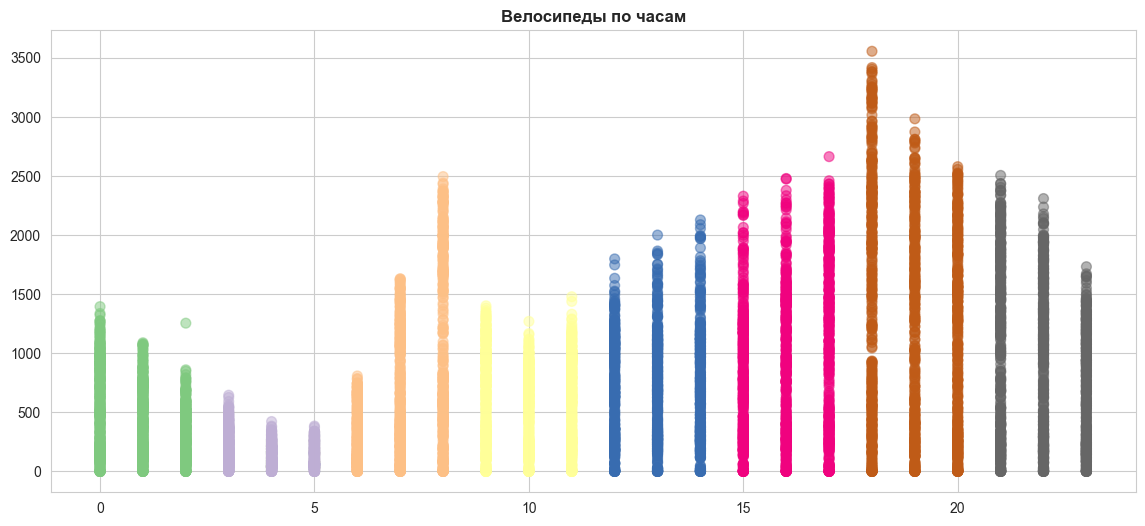

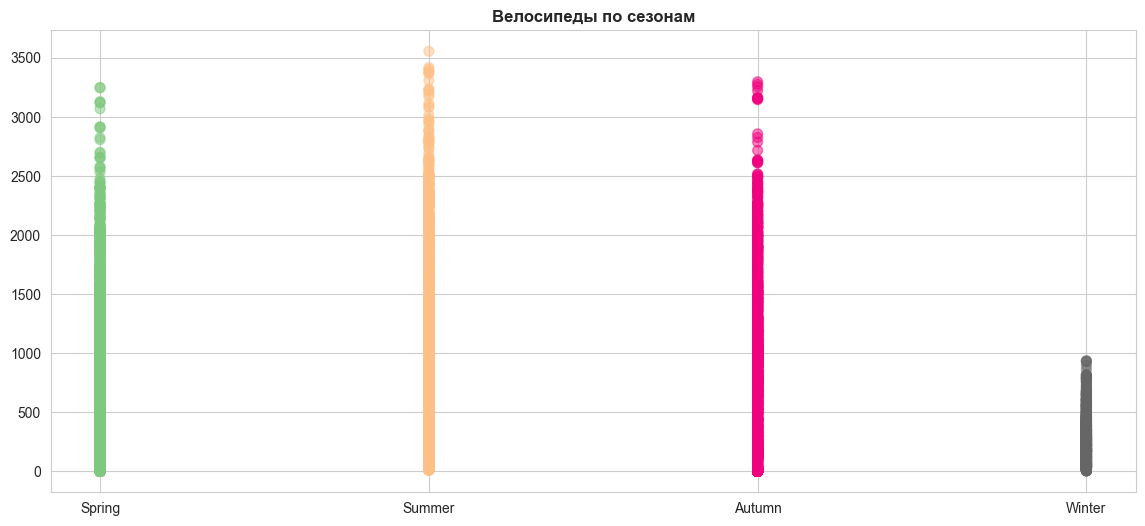

In [150]:
plt.figure(figsize=(14,6))
plt.scatter(x='Hour', y='Rented Bike Count', data=df, c='Hour', cmap='Accent', alpha=0.5, s=50)
plt.title('Велосипеды по часам')
plt.show()


plt.figure(figsize=(14,6))
plt.scatter(x='Seasons', y='Rented Bike Count', data=df, c='Seasons', cmap='Accent', alpha=0.5, s=50)
plt.xticks(ticks=list(seasons_dict.values()), labels=list(seasons_dict.keys()))
plt.title('Велосипеды по сезонам')
plt.show()

## Проверим корреляцию признаков

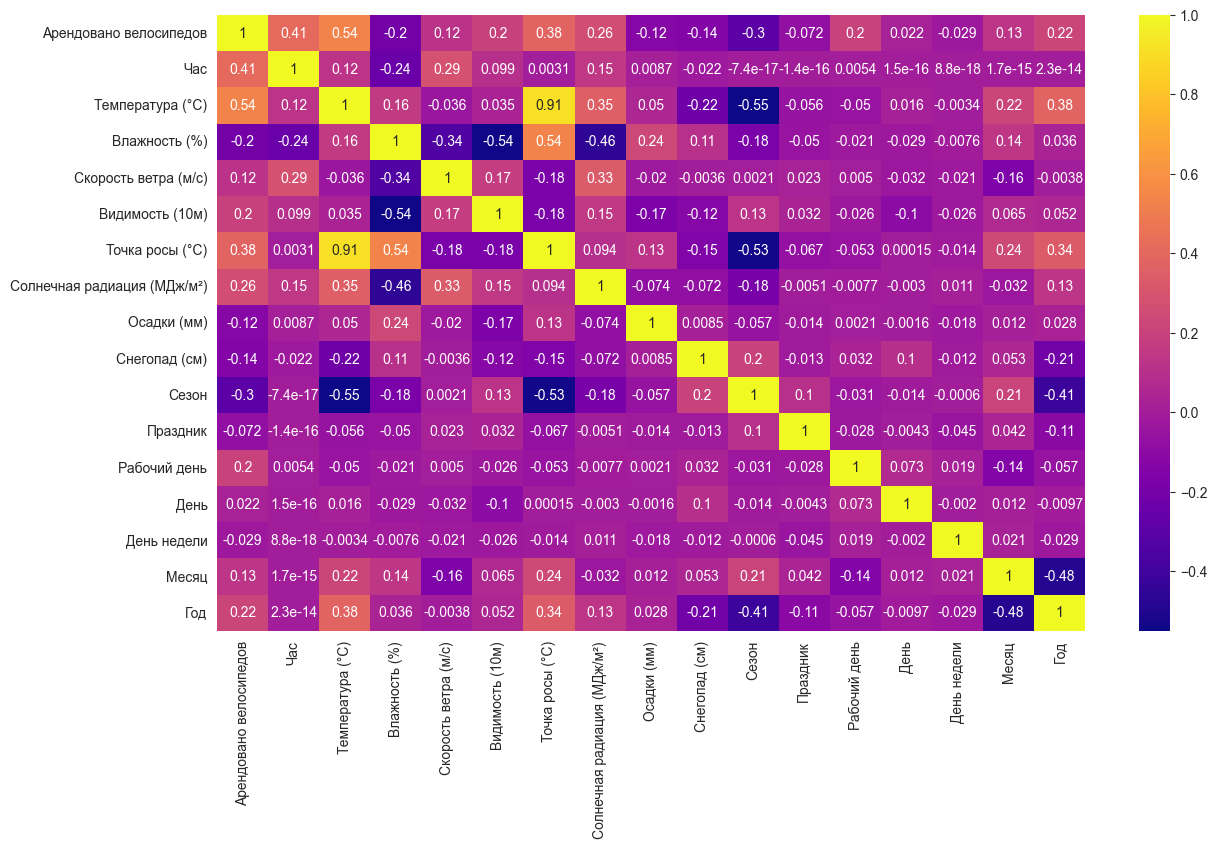

In [183]:
corr = df.corr()

# Переименовываем индексы и колонки
corr_rus = corr.rename(index=columns_translation, columns=columns_translation)

plt.figure(figsize=(14,8))
sns.heatmap(corr_rus,annot=True,cbar=True,cmap='plasma')
plt.show()

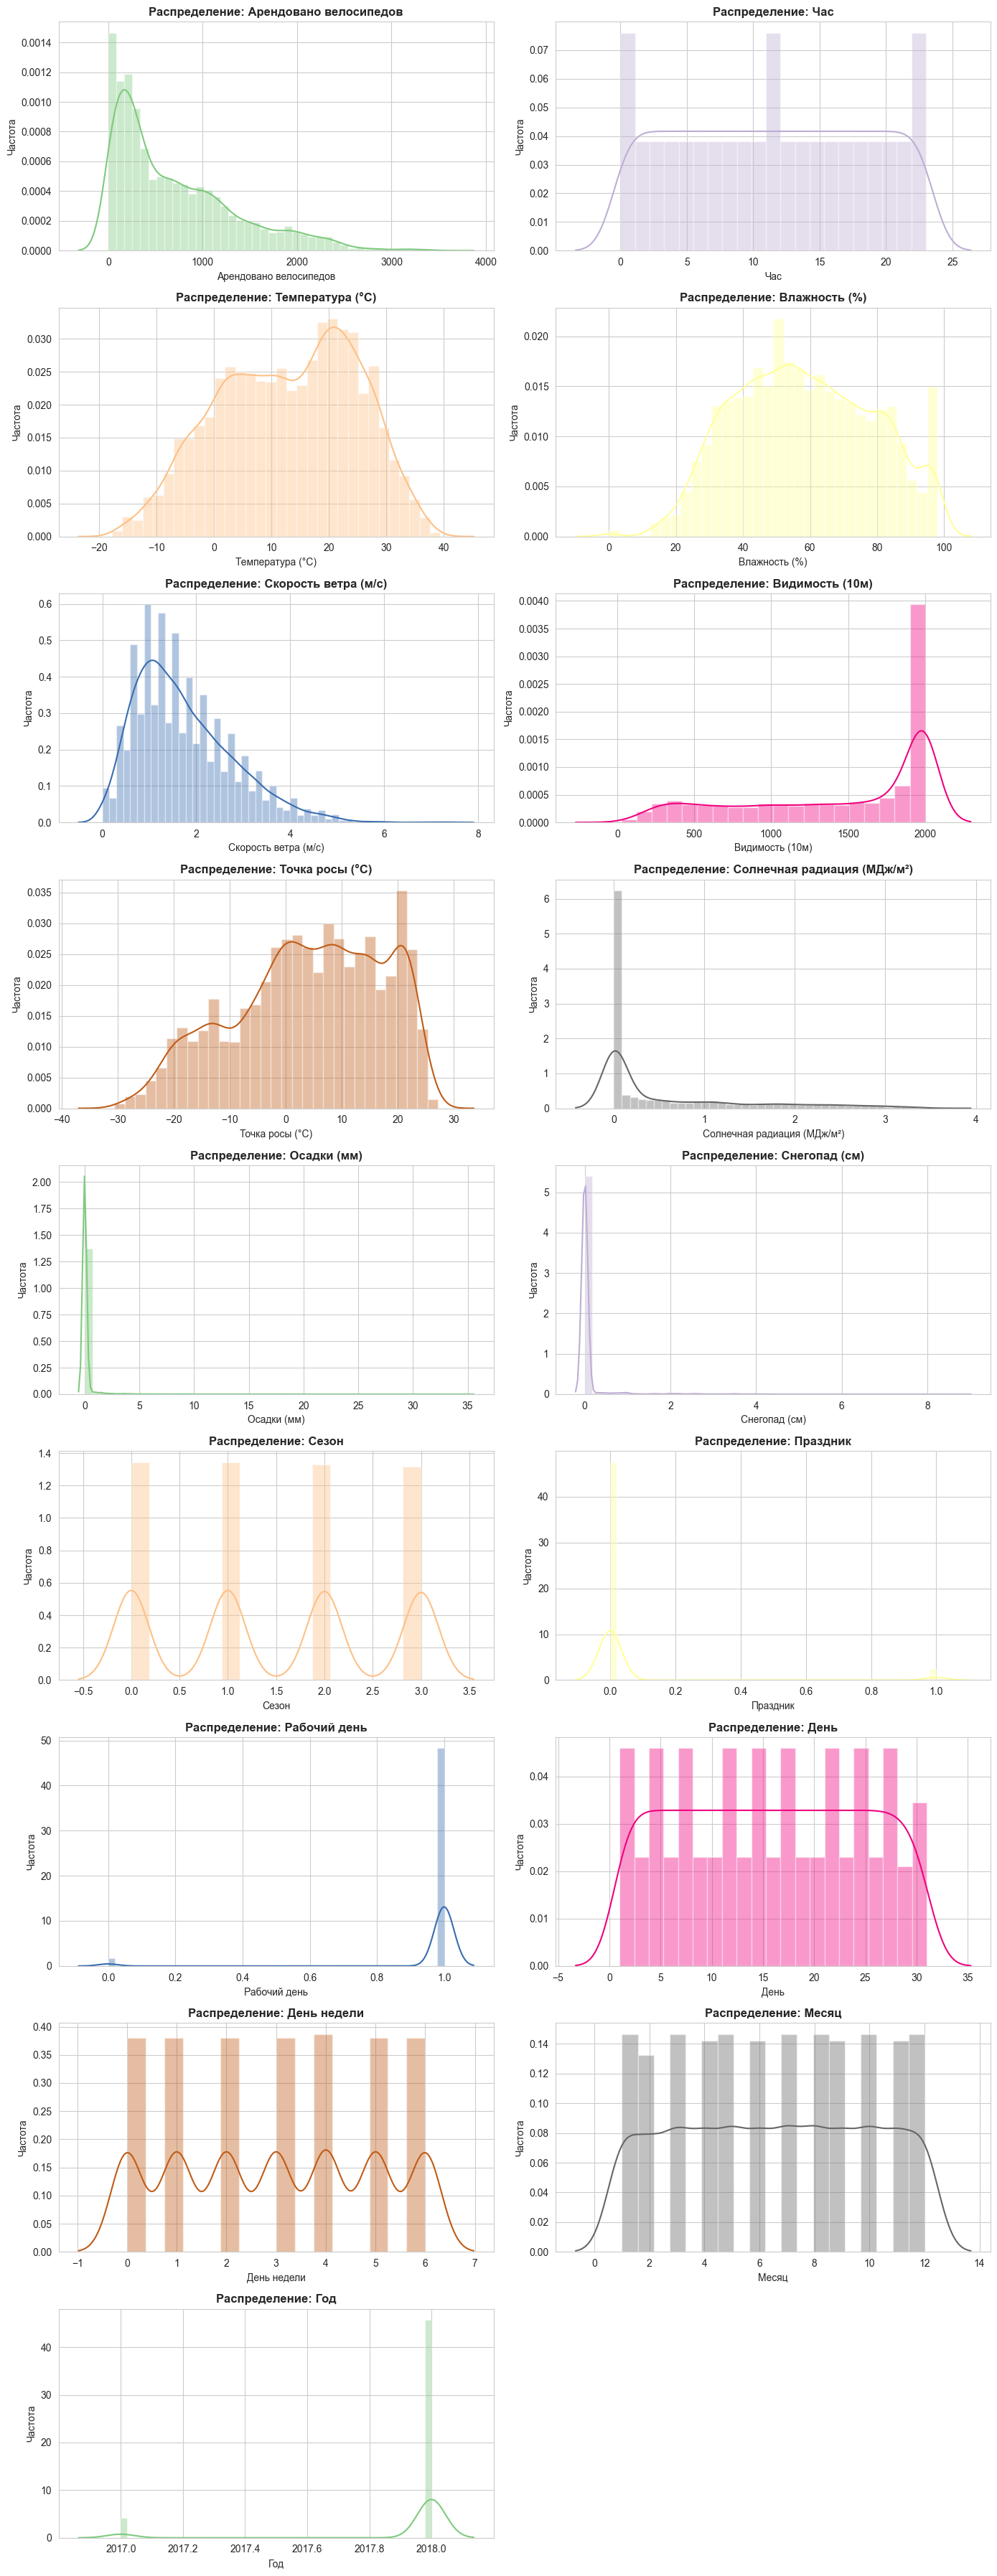

In [27]:
# Стиль графиков
sns.set_style("whitegrid")
plt.rcParams['axes.titleweight'] = 'bold'

# Настройка сетки подграфиков
num_cols = 2
num_rows = -(-len(df.columns) // num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, num_rows * 4))
axes = axes.flatten()

# Палитра цветов
colors = sns.color_palette("Accent", len(df.columns))

for i, col in enumerate(df.columns):
    rus_name = columns_translation.get(col, col)
    sns.distplot(df[col], color=colors[i], ax=axes[i])
    axes[i].set_title(f'Распределение: {rus_name}')
    axes[i].set_xlabel(rus_name)
    axes[i].set_ylabel('Частота')

# Удаляем лишние подграфики
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Разбиваем данные для train/test и стандартизируем данные

In [3]:
x = df.drop(['Rented Bike Count'],axis=1)
y = df['Rented Bike Count']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(7008, 16)
(7008,)
(1752, 16)
(1752,)


In [4]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # медиана устойчивее к выбросам
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, x.columns)
    ])

# rfr = RandomForestRegressor(
#         n_estimators=100, 
#         max_depth=20,
#         random_state=42,
#         n_jobs=-1
#     )

# model_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('regressor', rfr)
# ])

## Метод для обучения и проверки моделей

Для проверки стабильности моделей используем кросс-валидацию (5 фолдов)

In [5]:
# Функция для обучения и оценки модели
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Создаем пайплайн с моделью
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Обучение
    pipeline.fit(X_train, y_train)
    
    # Предсказания
    y_pred = pipeline.predict(X_test)
    
    # Метрики
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Кросс-валидация
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    
    return {
        'Model': model_name,
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae,
        'CV R² mean': cv_scores.mean(),
        'CV R² std': cv_scores.std(),
        'Pipeline': pipeline  # сохраняем для дальнейшего использования
    }

## Baseline

In [6]:
result = evaluate_model(LinearRegression(), x_train, y_train, x_test, y_test, 'LinearRegression')

# print(f"   R²: {result['R²']:.4f}, RMSE: {result['RMSE']:.2f}, MAE: {result['MAE']:.2f} \n",)

results_base = []
results_base.append(result)
results_base_df = pd.DataFrame(results_base)
results_base_df

,Model,R²,RMSE,MAE,CV R² mean,CV R² std,Pipeline
0,LinearRegression,0.53178,441.680981,331.459035,0.544978,0.017098,"(ColumnTransformer(transformers=[('num',\n ..."


## Проверяем дополнительные модели для предсказания

In [7]:
# Словарь моделей для сравнения
models = {
    
    'RidgeCV': RidgeCV(cv=5),
    
    'LassoCV': LassoCV(alphas=[0.1, 1.0, 10.0], cv=5, random_state=42, max_iter=10000),
    
    'ElasticNetCV': ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=[0.1, 1.0, 10.0],
        cv=5,
        random_state=42,
        max_iter=10000
    ),
    
    'RandomForest': RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),
    
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    ),
    
    'CatBoost': CatBoostRegressor(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        random_seed=42,
        verbose=0,  # отключаем вывод
        loss_function='RMSE'
    )
}

# Сравниваем все модели
results = []
for name, model in models.items():
    print(f"Обучение {name}...")
    result = evaluate_model(model, x_train, y_train, x_test, y_test, name)
    results.append(result)
    print(f"   R²: {result['R²']:.4f}, RMSE: {result['RMSE']:.2f}\n")

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)

results_df

Обучение RidgeCV...
   R²: 0.5318, RMSE: 441.67

Обучение LassoCV...
   R²: 0.5314, RMSE: 441.86

Обучение ElasticNetCV...
   R²: 0.5318, RMSE: 441.68

Обучение RandomForest...
   R²: 0.9288, RMSE: 172.18

Обучение GradientBoosting...
   R²: 0.9210, RMSE: 181.41

Обучение CatBoost...
   R²: 0.9452, RMSE: 151.04



,Model,R²,RMSE,MAE,CV R² mean,CV R² std,Pipeline
0,CatBoost,0.945243,151.044011,89.913895,0.946297,0.003557,"(ColumnTransformer(transformers=[('num',\n ..."
1,RandomForest,0.928846,172.180598,97.713674,0.926334,0.006025,"(ColumnTransformer(transformers=[('num',\n ..."
2,GradientBoosting,0.921014,181.408483,109.952499,0.927627,0.005032,"(ColumnTransformer(transformers=[('num',\n ..."
3,RidgeCV,0.531799,441.672267,331.355739,0.545073,0.017039,"(ColumnTransformer(transformers=[('num',\n ..."
4,ElasticNetCV,0.531772,441.684913,330.819656,0.545082,0.016646,"(ColumnTransformer(transformers=[('num',\n ..."
5,LassoCV,0.531408,441.856333,331.334838,0.544914,0.016776,"(ColumnTransformer(transformers=[('num',\n ..."


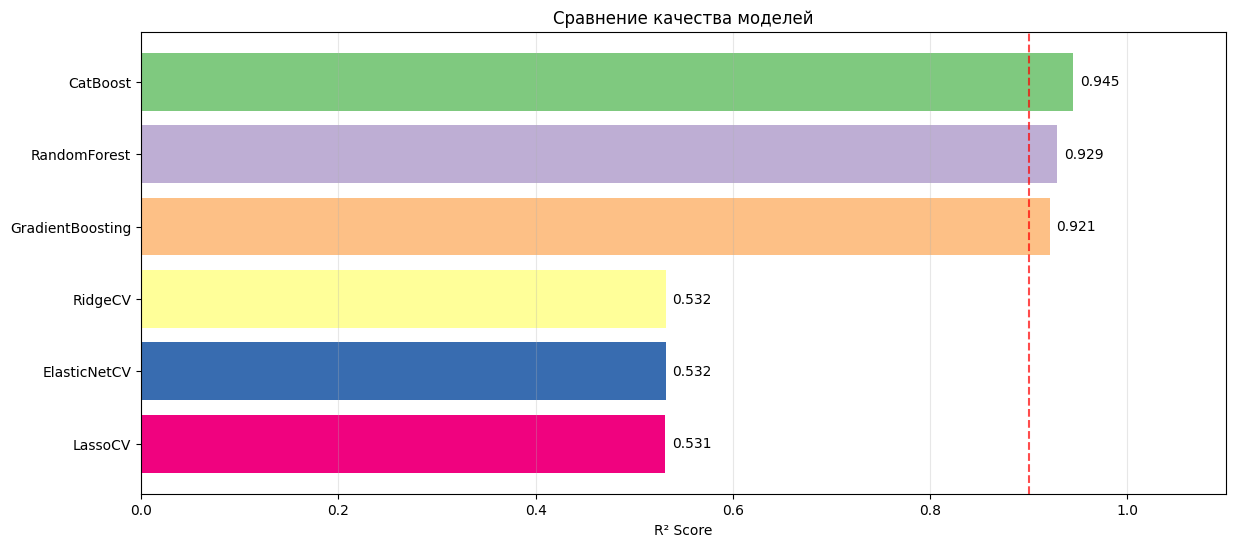

In [11]:
models = results_df['Model']
r2_scores = results_df['R²']

plt.figure(figsize=(14,6))
bars = plt.barh(results_df['Model'], results_df['R²'], color=plt.cm.Accent(range(len(results_df))))
plt.bar_label(bars, fmt='%.3f', padding=5)
plt.axvline(x=0.9, color='red', linestyle='--', alpha=0.7)
plt.xlabel('R² Score')
plt.title('Сравнение качества моделей')
plt.xlim(0, 1.1)
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.show()

 1. Час                       34.6180
 2. Температура (°C)          17.7861
 3. Рабочий день              8.9875
 4. Солнечная радиация (МДж/м²) 8.9811
 5. Влажность (%)             6.3784
 6. День недели               4.9124
 7. Сезон                     4.9063
 8. Осадки (мм)               4.0197
 9. Месяц                     3.9153
10. Точка росы (°C)           2.7751


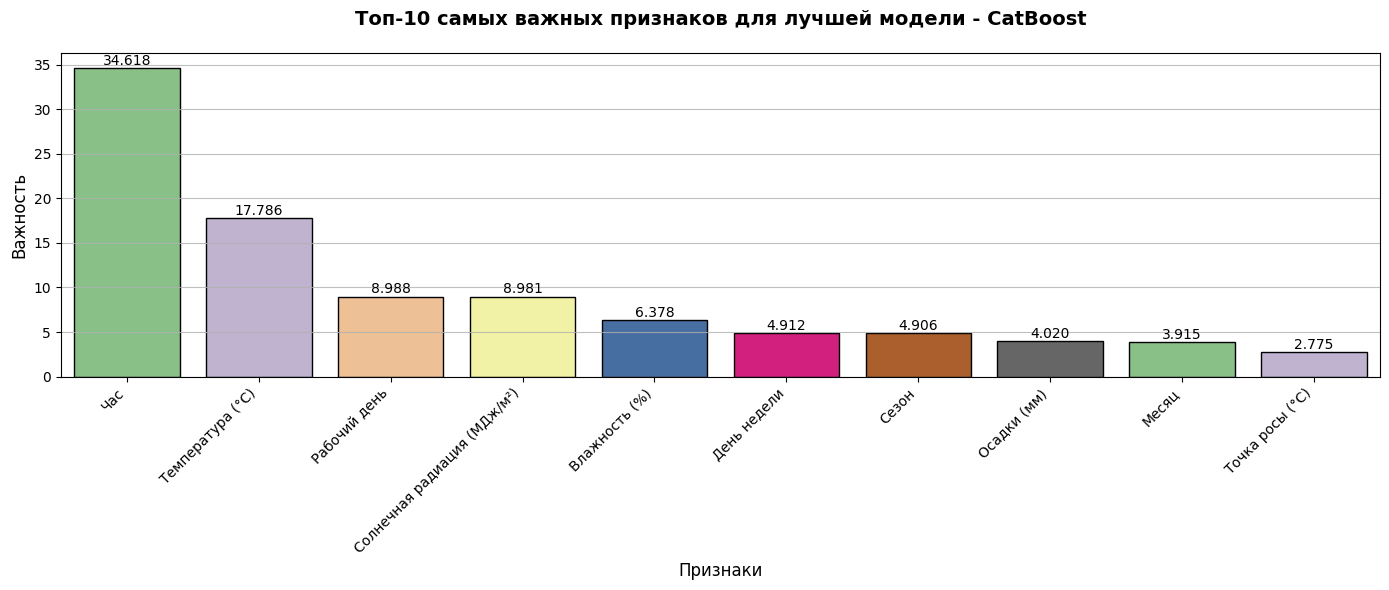

In [13]:
best_pipeline = results_df.iloc[0]['Pipeline']
best_model = best_pipeline.named_steps['regressor']
best_model_name = results_df.iloc[0]['Model']


feature_names = x.columns.tolist()

importances = pd.Series(
    best_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

importances_rus = importances.rename(index=columns_translation)


for i, (name, val) in enumerate(importances_rus.head(10).items(), 1):
    print(f"{i:2d}. {name:25} {val:.4f}")

plt.figure(figsize=(14,6))
# Визуализация с русскими названиями
ax = sns.barplot(x=importances_rus.head(10).index, 
                 y=importances_rus.head(10).values,
                 palette='Accent',
                 edgecolor='black',
                 linewidth=1)

plt.title(f'Топ-10 самых важных признаков для лучшей модели - {best_model_name}', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Признаки', fontsize=12)
plt.ylabel('Важность', fontsize=12)

# Добавляем значения на столбцы
for i, v in enumerate(importances_rus.head(10)):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.8)
plt.tight_layout()
plt.show()

## Сохраняем инференс лучшей модели

In [14]:
model_path = f'data/{best_model_name}_bike_model.pkl'
joblib.dump(best_pipeline, model_path)

['data/CatBoost_bike_model.pkl']

## Выводы:

**Лучшая в данном эксперименте модель для предсказания CatBoost:**

Отличное качество: R² = 0.945 (объясняет 94.5% дисперсии)

Минимальные ошибки:

RMSE = 151.04 (наименьшая ошибка среди всех моделей)

MAE = 89.91 (среднее отклонение от реальных значений)

Высокая стабильность:

Кросс-валидация: R² = 0.946 ± 0.0036

Практически идеальное совпадение с тестовым результатом (0.945)

**Хорошие альтернативы:**

Random Forest: R² = 0.929, очень близок к лидеру

Gradient Boosting: R² = 0.921, также показывает отличные результаты

Все три ансамблевых метода значительно превосходят линейные модели

**Линейные модели показали низкую эффективность:**

RidgeCV, ElasticNet CV, LassoCV: R² ≈ 0.53

Ошибки в 2.5-3 раза выше, чем у лучших моделей

Причина: данные имеют сложные нелинейные зависимости, которые линейные модели не способны уловить


**Использование:**

Для дальнейшего использования выбираем CatBoost как лучшую модель. При необходимости можно рассмотреть Random Forest как более простую интерпретируемую альтернативу с близким качеством.